In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             matthews_corrcoef, f1_score)
from sklearn.tree import plot_tree                             
import os
import pickle

In [2]:
df = pd.read_csv("dataset/clean.csv")

X = df.drop(columns=['loan_status'])
y = df['loan_status']


X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [4]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8706
F1 Score (Macro): 0.7965
Matthews Correlation Coefficient (MCC): 0.5985

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4479
           1       0.75      0.61      0.67      1247

    accuracy                           0.87      5726
   macro avg       0.82      0.78      0.80      5726
weighted avg       0.86      0.87      0.87      5726



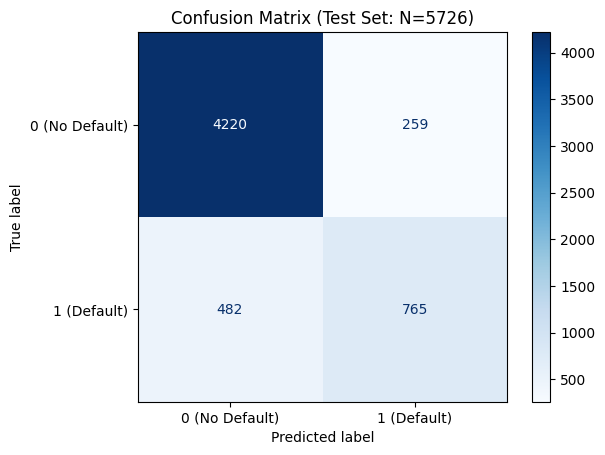

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 (No Default)", "1 (Default)"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Test Set: N=5726)")
plt.grid(False)
plt.show()

c:\Users\damar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


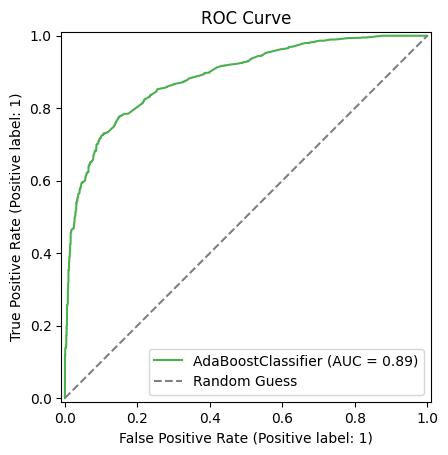

In [6]:
RocCurveDisplay.from_estimator(model, X_test, y_test, color="#4CAF50")
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.legend()
plt.show()

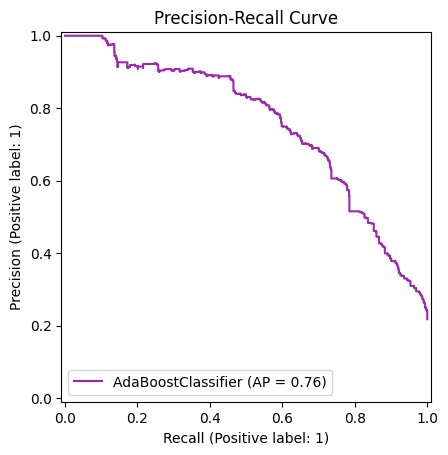

In [7]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, color="#9C27B0")
plt.title("Precision-Recall Curve")
plt.show()

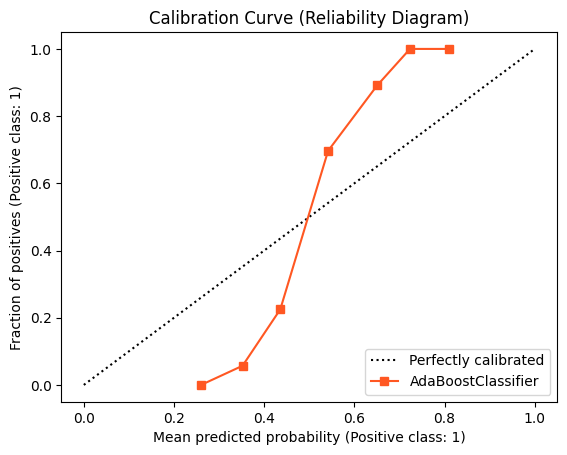

In [8]:
from sklearn.calibration import CalibrationDisplay

# 5. Calibration Curve (Reliability Diagram)
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, color='#FF5722')
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()

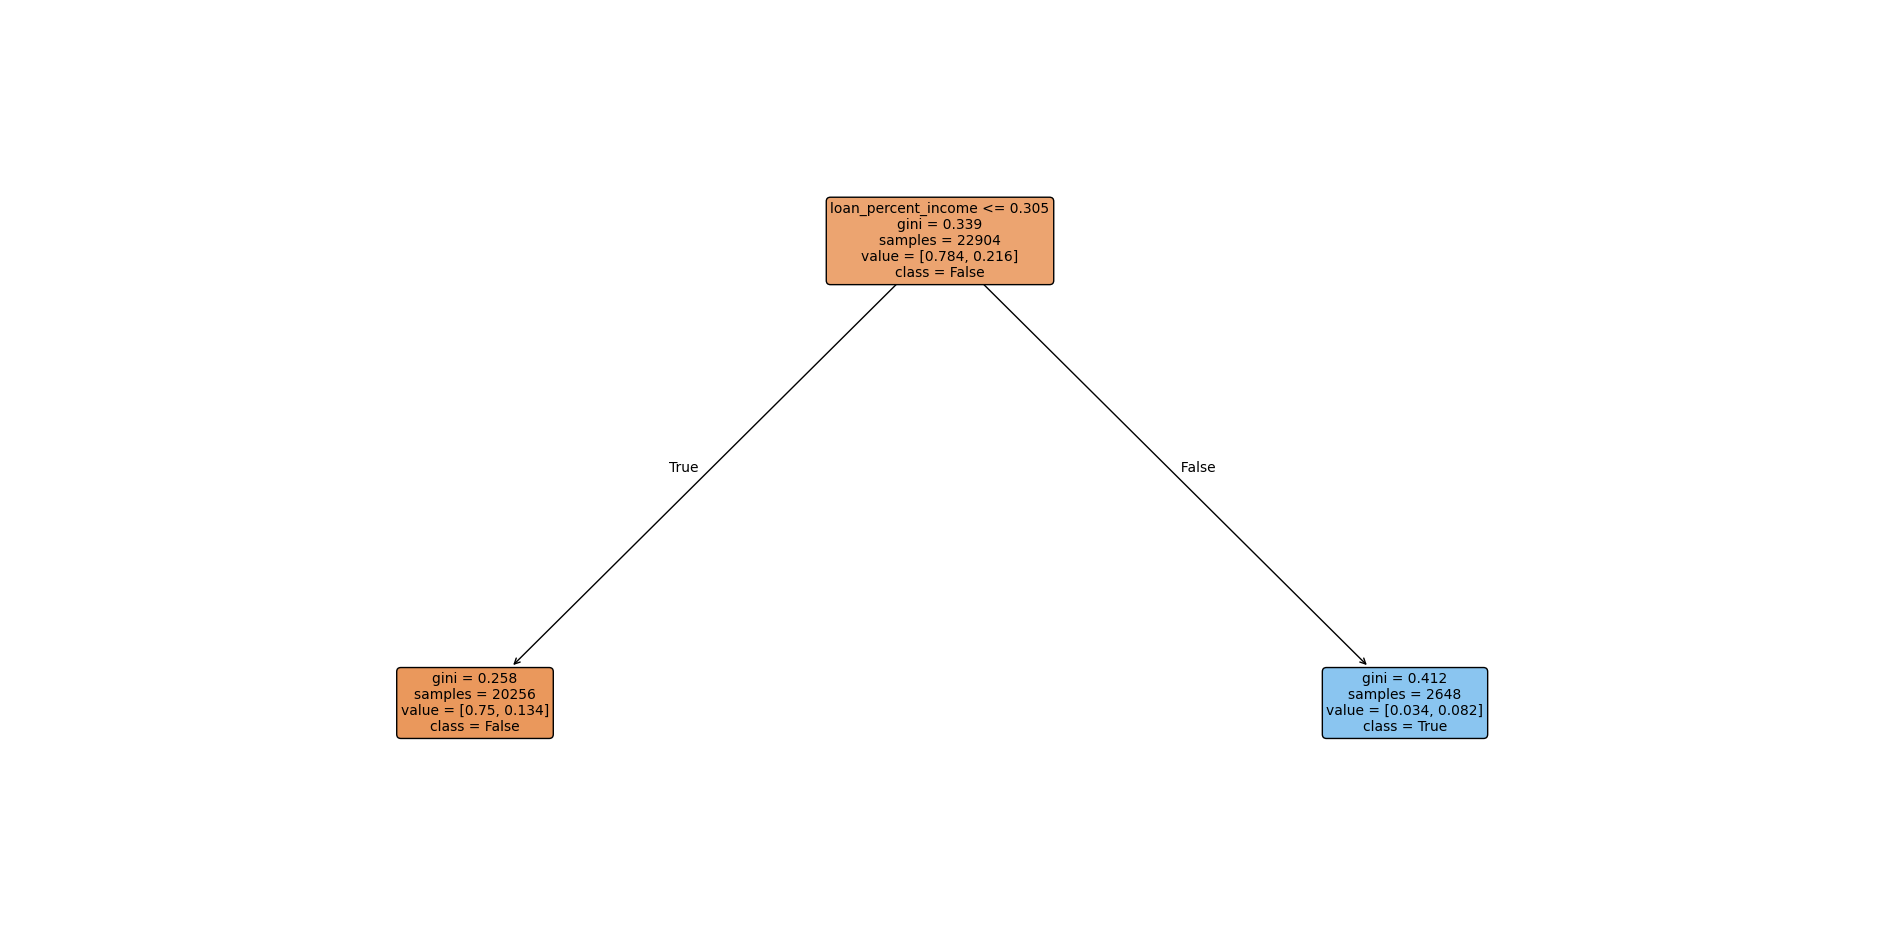

In [9]:
plt.figure(figsize=(24, 12))
first_tree = model.estimators_[0]
plot_tree(first_tree, 
          feature_names=X.columns, 
          class_names=["False", "True"], 
          filled=True, 
          rounded=True, 
          max_depth=3,
          fontsize=10)
plt.show()

In [10]:
os.makedirs("model_save", exist_ok=True)
model_path = "model_save/adaboost.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model successfully saved to {model_path}")

Model successfully saved to model_save/adaboost.pkl
